### Setting up the API

In [3]:
import numpy as np
import pandas as pd
from utils.subroutines import subroutine_familywise
from utils.multiple_testing import eBH, e_function_static
from utils.helper_functions import compute_fdp, compute_power
from utils.generating_data import gen_data

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.svm import OneClassSVM


In [4]:
from openai import OpenAI
client = OpenAI(api_key="")

def gen_data_LLM(n, prompt, prompt_injection):
    data = []
    for i in range(n):
        print(prompt+' '+prompt_injection)
        response = client.responses.create(
        model="gpt-4o-mini-2024-07-18",
        input=prompt+' '+prompt_injection
        )
        data.append(response.output_text)
    return np.array(data)

In [229]:
import numpy as np
import pandas as pd
from utils.subroutines import subroutine_familywise, subroutine
from utils.multiple_testing import eBH, e_function_static
from utils.helper_functions import compute_fdp, compute_power
from utils.generating_data import gen_data

from utils.Adadetect import AdaDetectERM 
from sklearn.ensemble import IsolationForest, RandomForestClassifier

n =2000
m= 30
K_blocks = 1
alpha_fdr = 0.05
adjustment = 0.5

#OneClassSVM(nu=0.8, kernel='rbf', gamma='scale') 
#IsolationForest(max_samples=1.0, n_estimators=50)
Classifier = OneClassSVM(nu=0.8, kernel='rbf', gamma='scale') 

blocks = np.array_split(np.arange(m), K_blocks)
baseline_score_matrix = subroutine(Classifier, Xref, Xtest, blocks) 

test_weights = np.ones(m)
cal_weights = np.ones(n)

e_values_KFC = e_function_static(adjustment*alpha_fdr, baseline_score_matrix, cal_weights, test_weights)

e_rej = eBH(e_values_KFC, alpha_fdr)
print(e_rej)

proc = AdaDetectERM(scoring_fn = Classifier, split_size=4000/5000) 
rej = proc.apply(Xtest, alpha_fdr, Xref)
print(rej)

ValueError: operands could not be broadcast together with shapes (1000,) (2000,) 

In [56]:
def clean_prompts(prompts: list):
    cleaned = []
    for prompt in prompts:
        before, _, after = prompt.partition(":")
        cleaned.append(before)
    return cleaned

def 

In [274]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import random
# 'all-mpnet-base-v2' - large space (768)
#'all-MiniLM-L6-v2' - smaller space (384)
embedder = SentenceTransformer('all-MiniLM-L6-v2')

#Getting the adversarial prompts
ds_adversarial = load_dataset("Chetan-k-p/adversarial-prompts")
all_prompts = ds_adversarial['train']['instruction']

props_outliers = np.arange(0.1,0.7,0.1)
n = 2500
m = 100
n_exp = 1000
K_blocks = 20
adjustment = 0.75
alpha_fdr = 0.1
threshold = 70 #how many symbols in an adversarial prompt
valid_prompts = [all_prompts[i] for i in range(len(all_prompts)) if len(all_prompts[i]) <= threshold]
n_outliers = int(np.ceil(m * prop_outliers))

#Classifier we're going to use
#OneClassSVM(nu=0.004, kernel='rbf', gamma='scale')
#IsolationForest(max_samples=1.0, n_estimators=50)
classifier_KFC = IsolationForest(max_samples=1.0, n_estimators=50)
classifier = OneClassSVM(nu=0.004, kernel='rbf', gamma='scale')
#classifier_name = 'Isolation Forest'

block_range = [1, 2, 5, 10, 20, 50]

for K_blocks in block_range:
    results_power = {'KFC':[], 'Adadetect': [], 'SC': []}
    results_fdr = {'KFC':[], 'Adadetect': [], 'SC': []}
    
    for prop_outliers in props_outliers:
        exp_results_power = {'KFC':[], 'Adadetect': [], 'SC': []}
        exp_results_fdr = {'KFC':[], 'Adadetect': [], 'SC': []}
        for exp in range(n_exp):
            np.random.seed(exp)
            n_outliers = int(np.ceil(m * prop_outliers))
            
            perm0 = np.random.permutation(len(all_prompts))
            Xref = clean_prompts([ all_prompts[i] for i in np.sort(perm0[:n]) ])
            
            perm = np.random.permutation(m) 
            nonzero = np.sort(perm[:n_outliers])
            nulls = np.sort(perm[n_outliers:])
            
            # don't generate test dataset under covariate shift
            Xtest0 = clean_prompts([ all_prompts[i] for i in np.sort(perm0[n:n+m-n_outliers]) ])# inliers 
            Xtest1 = random.sample(valid_prompts, n_outliers) # outliers
            
            # weights are just ones vector
            test_weights = np.ones(m)
            cal_weights = np.ones(n)
            
            Xtest = np.empty(m, dtype=object)
            Xtest[nonzero] = Xtest1
            Xtest[nulls] = Xtest0
        
            Xref = embedder.encode(Xref)
            Xtest = embedder.encode(Xtest)
            
            # KFC    
            blocks = np.array_split(np.arange(m), K_blocks)
            baseline_score_matrix = subroutine(classifier_KFC, Xref, Xtest, blocks) 
            
            test_weights = np.ones(m)
            cal_weights = np.ones(n)
            e_values_KFC = e_function_static(adjustment*alpha_fdr, baseline_score_matrix, cal_weights, test_weights)
            e_rej = eBH(e_values_KFC, alpha_fdr)
        
            exp_results_power['KFC'].append(compute_power(e_rej, nonzero))
            exp_results_fdr['KFC'].append(compute_fdp(e_rej, nulls))
        
            #Adadetect
            proc = AdaDetectERM(scoring_fn = classifier, split_size=4000/5000) 
            rej = proc.apply(Xtest, alpha_fdr, Xref)
            
            exp_results_power['Adadetect'].append(compute_power(rej, nonzero))
            exp_results_fdr['Adadetect'].append(compute_fdp(rej, nulls))
        
            #SC 
            train_prop = 0.5   # this is a tuning hyperparameter
            SC_n_train = int(n * train_prop)
            SC_train_split = np.random.permutation(n)
            Xtrain_split = Xref[SC_train_split[:SC_n_train]].copy()
            Xcalib_split = Xref[SC_train_split[SC_n_train:]].copy()
            
            classifier.fit(Xtrain_split)
            calib_scores = classifier.score_samples(Xcalib_split).flatten()
            test_scores = classifier.score_samples(Xtest).flatten()
            
            score_matrix_SC = -1 * np.tile(np.concatenate([calib_scores, test_scores]), (m, 1))
            
            # make split conformal e-values
            split_e_values = e_function_static(alpha_fdr, score_matrix_SC, cal_weights[SC_train_split[SC_n_train:]], test_weights)
            split_e_rej = eBH(split_e_values, alpha_fdr)
            
            exp_results_power['SC'].append(compute_power(split_e_rej, nonzero))
            exp_results_fdr['SC'].append(compute_fdp(split_e_rej, nulls))
        
        print('Power KFC', np.mean(exp_results_power['KFC']), 'Power Adadetect', np.mean(exp_results_power['Adadetect']), 
                                                                                        'Power SC', np.mean(exp_results_power['SC']))
        results_power['KFC'].append(exp_results_power['KFC'])
        results_power['Adadetect'].append(exp_results_power['Adadetect'])
        results_power['SC'].append(exp_results_power['SC'])
        
        results_fdr['KFC'].append(exp_results_fdr['KFC'])
        results_fdr['Adadetect'].append(exp_results_fdr['Adadetect'])
        results_fdr['SC'].append(exp_results_fdr['SC'])
        
    power_df = pd.DataFrame(results_power).add_prefix('power_')
    fdr_df = pd.DataFrame(results_fdr).add_prefix('fdr_')
    results_df = pd.concat([power_df, fdr_df], axis = 1)
    results_df['props_outliers'] = props_outliers
    results_df.to_csv(f'results_with_{K_blocks}_blocks.csv', index=False)


Power KFC 0.5556 Power Adadetect 0.0 Power SC 0.067
Power KFC 0.8132999999999999 Power Adadetect 0.0 Power SC 0.065
Power KFC 0.8692903225806451 Power Adadetect 0.0 Power SC 0.069
Power KFC 0.7718250000000001 Power Adadetect 0.0 Power SC 0.066
Power KFC 0.6164200000000001 Power Adadetect 0.0 Power SC 0.065
Power KFC 0.4258032786885246 Power Adadetect 0.0 Power SC 0.055
Power KFC 0.5337000000000001 Power Adadetect 0.0 Power SC 0.065
Power KFC 0.8011 Power Adadetect 0.0 Power SC 0.07
Power KFC 0.9615483870967741 Power Adadetect 0.0 Power SC 0.057
Power KFC 0.966 Power Adadetect 0.0 Power SC 0.061
Power KFC 0.9062800000000001 Power Adadetect 0.0 Power SC 0.055
Power KFC 0.8576721311475409 Power Adadetect 0.0 Power SC 0.057
Power KFC 0.44489999999999996 Power Adadetect 0.0 Power SC 0.052
Power KFC 0.7910499999999999 Power Adadetect 0.0 Power SC 0.065
Power KFC 0.9646774193548387 Power Adadetect 0.0 Power SC 0.057
Power KFC 0.9964 Power Adadetect 0.0 Power SC 0.059
Power KFC 0.9976400000000

KeyboardInterrupt: 

In [266]:
power_df = pd.DataFrame(results_power).add_prefix('power_')
fdr_df = pd.DataFrame(results_fdr).add_prefix('fdr_')
results_df = pd.concat([power_df, fdr_df], axis = 1)
results_df['props_outliers'] = props_outliers
results_df.to_csv(f'results_with_{K_blocks}_blocks.csv', index=False)

In [333]:
import ast

K_blocks = 10
df = pd.read_csv(f'results_with_{K_blocks}_blocks.csv')
props_outliers = df.pop('props_outliers').values
results_power = df.filter(regex=r'^power_') \
             .rename(columns=lambda c: c[len('power_'):])
results_power = results_power.applymap(lambda s: np.array(ast.literal_eval(s)))
results_fdr  = df.filter(regex=r'^fdr_') \
             .rename(columns=lambda c: c[len('fdr_'):])
results_fdr = results_fdr.applymap(lambda s: np.array(ast.literal_eval(s)))

/var/folders/54/btrgqywd325_yg5yl79r402c0000gn/T/ipykernel_18183/3476601692.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_power = results_power.applymap(lambda s: np.array(ast.literal_eval(s)))
/var/folders/54/btrgqywd325_yg5yl79r402c0000gn/T/ipykernel_18183/3476601692.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_fdr = results_fdr.applymap(lambda s: np.array(ast.literal_eval(s)))


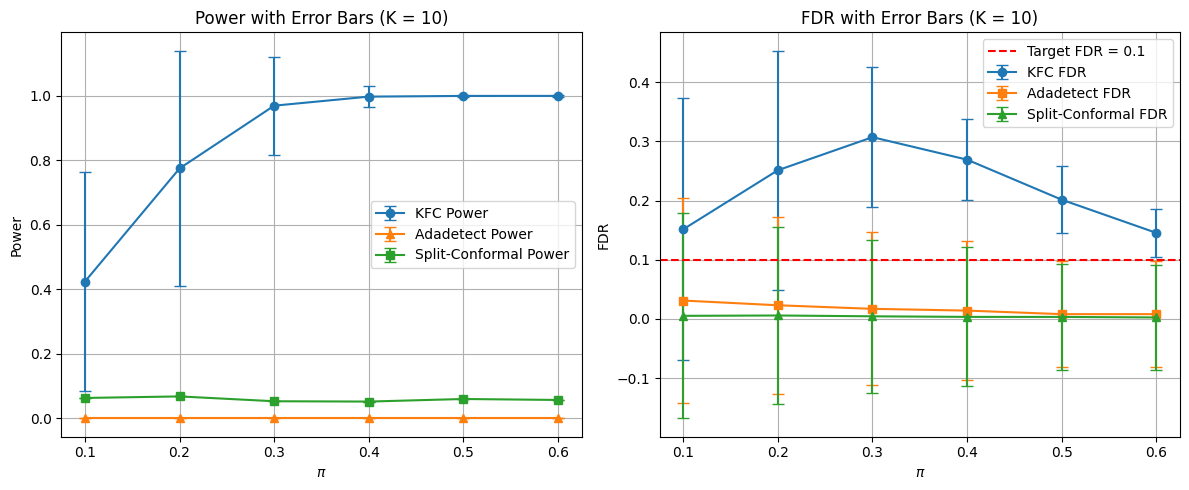

In [335]:
import matplotlib.pyplot as plt

FDR_KFC = []
err_FDR_KFC = []

FDR_Adadetect = []
err_FDR_Adadetect = []

FDR_SC = []
err_FDR_SC = []

power_KFC = []
err_power_KFC = []

power_Adadetect = []
err_power_Adadetect = []

power_SC = []
err_power_SC = []

for idx, pi in enumerate(props_outliers):
    FDR_KFC.append(np.mean(results_fdr['KFC'][idx]))
    FDR_Adadetect.append(np.mean(results_fdr['Adadetect'][idx]))
    FDR_SC.append(np.mean(results_fdr['SC'][idx]))
    
    err_FDR_KFC.append(np.std(results_fdr['KFC'][idx]))
    err_FDR_Adadetect.append(np.std(results_fdr['Adadetect'][idx]))
    err_FDR_SC.append(np.std(results_fdr['Adadetect'][idx]))

    power_KFC.append(np.mean(results_power['KFC'][idx]))
    power_Adadetect.append(np.mean(results_power['Adadetect'][idx]))
    power_SC.append(np.mean(results_power['SC'][idx]))
    
    err_power_KFC.append(np.std(results_power['KFC'][idx]))
    err_power_Adadetect.append(np.std(results_power['Adadetect'][idx]))
    err_power_SC.append(np.std(results_power['Adadetect'][idx]))
    
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot power with error bars
axes[0].errorbar(props_outliers, power_KFC, yerr=err_power_KFC, fmt='-o', capsize=4, label='KFC Power')
axes[0].errorbar(props_outliers, power_Adadetect, yerr=err_power_Adadetect, fmt='-^', capsize=4, label='Adadetect Power')
axes[0].errorbar(props_outliers, power_SC, yerr=err_power_SC, fmt='-s', capsize=4, label='Split-Conformal Power')
axes[0].set_xlabel(r'$\pi$')
axes[0].set_ylabel('Power')
axes[0].set_title(f'Power with Error Bars (K = {K_blocks})')
axes[0].legend()
axes[0].grid(True)

# Plot FDR with error bars
axes[1].errorbar(props_outliers, FDR_KFC, yerr=err_FDR_KFC, capsize=4, fmt='-o', label='KFC FDR')
axes[1].errorbar(props_outliers, FDR_Adadetect, yerr=err_FDR_Adadetect, fmt='-s',capsize=4, label='Adadetect FDR')
axes[1].errorbar(props_outliers, FDR_SC, yerr=err_FDR_SC,  fmt='-^',capsize=4, label='Split-Conformal FDR')
axes[1].axhline(y=alpha_fdr, color='red', linestyle='--', label=f'Target FDR = {alpha_fdr}')
axes[1].set_xlabel(r'$\pi$')
axes[1].set_ylabel('FDR')
axes[1].set_title(f'FDR with Error Bars (K = {K_blocks})')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [535]:

train_prop = 0.5   # this is a tuning hyperparameter
SC_n_train = int(n * train_prop)
SC_train_split = np.random.permutation(n)
Xtrain_split = Xref[SC_train_split[:SC_n_train]].copy()
Xcalib_split = Xref[SC_train_split[SC_n_train:]].copy()

Classifier.fit(Xtrain_split)
calib_scores = Classifier.score_samples(Xcalib_split).flatten()
test_scores = Classifier.score_samples(Xtest).flatten()

score_matrix_SC = -1 * np.tile(np.concatenate([calib_scores, test_scores]), (m, 1))

# make split conformal e-values
split_e_values = e_function_static(alpha_fdr, score_matrix_SC, cal_weights[SC_train_split[SC_n_train:]], test_weights)
print(split_e_values)
split_e_rej = eBH(split_e_values, alpha_fdr)

print(split_e_rej)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
[]


In [28]:
from utils.multiple_testing import p_function_static
from collections import defaultdict

p_values = p_function_static(baseline_score_matrix, cal_weights, test_weights)
p_rej = eBH(1/p_values, alpha_fdr)
guarantee = True

fold_memberships = {}    # compute which blocks each test point belong to
lofo_fold_dict = {}
for fold_idx, fold in enumerate(blocks):
    for j in fold:
        fold_memberships[j] = fold_idx
    lofo_fold_dict[fold_idx] = [f for idx, f in enumerate(blocks) if idx != fold_idx] # only need to do this slow list comprehension once per fold

## we will CC in ascending order of the p-values --- but there are ties. compute the strata of the p-values
p_values_normalized = np.rint(p_values * (n+1)).astype(int)
sorted_idxs = np.argsort(p_values_normalized)
# sorted_idxs = np.argsort(p_values)

strata = defaultdict(list)
for idx in sorted_idxs:
    strata[p_values_normalized[idx]].append(idx) 

e_boost = np.zeros(m)
 
# now resample the scores
resampled_score_dict = {}

cc_fail_counter = 0
for key in strata:
    p_value_stratum = strata[key]

    cc_fail_inidicator_stratum = 1    # specific fail counter within the stratum, set it to True and make it False if we succeed
    for j in p_value_stratum: #sorted_idxs: #p_value_stratum:

        if guarantee:
            if j in e_rej:
                e_boost[j] = np.inf
                cc_fail_counter = 0 
                continue

        if cc_fail_counter >= 2:
            break 

        # determine which fold contains idx
        fold = blocks[fold_memberships[j]]
        lofo_folds = lofo_fold_dict[fold_memberships[j]]

        # compute the auxiliary statistic we need
        lofo_fold_membership_idxs = np.array([L[0] for L in lofo_folds])
        # specific test point
        Xj = Xtest[j]

        # begin the retraining/resampling steps
        resampled_scores_list = np.zeros((n+1, m, n+m))
        for i in range(n):
            # in this case, Z_i and Z_{n+j} are switched
            # the fold which j belongs to leads to scores which are unchanged by this switch
            # so we only retrain the folds for which j does not belong to
            Xi = Xref[i]

            Xref_resample = np.vstack((Xref[:i], Xj, Xref[(i+1):]))
            Xtest_resample = np.vstack((Xtest[:j], Xi, Xtest[(j+1):]))

            scores_resample = subroutine(Classifier, Xref_resample, Xtest_resample, lofo_folds)  

            # the current fold is not scored yet... but nothing has changed, except we should change i and n+j
            scores_for_current_fold = baseline_score_matrix[fold,:].copy()
            scores_for_current_fold[:, [i, (n+j)]] = scores_for_current_fold[:, [(n+j), i]]

            scores_resample[fold,:] = scores_for_current_fold

            # save the resamples
            resampled_scores_list[i,:,:] = scores_resample
        resampled_scores_list[n,:,:] = real_score_matrix  # when Z_{n+j} is switched with itself, nothing changes

        # now, we make the boosted e-values
        # if we used randomness to make p-values, then this is for integrating out the randomness
        boosting_start_time = time.time()
        if deterministic and randomness != 0:
            # if we want our boosted e-value to be deterministic, we must integrate out the randomness coming from U
            if randomness > 1:
                outer_integral = CC_grid_double( 
                        resampled_scores_list, cal_weights, test_weights, alpha_fdr, 
                        randomness, observed_statistic, hatR_statistic,
                        j
                    )
                e_boost[j] = m/alpha_fdr * outer_integral    # int_0^1 e_j^b(U), in a discrete way
            elif randomness == 1:
                assert False
            else:
                # here, there was no randonmness in the p-value to begin with
                assert False
        else:
            # in this case, we are fine with randomness, and simply returning e_j(U) --- or o/w there was no randomness in the first place
            if randomness > 1 or randomness == 0:
                c_U = observed_statistic(real_score_matrix, cal_weights, test_weights, U, alpha_fdr, j)
                cond_expectation, numerical_error = CC_grid(
                    c_U, 
                    resampled_scores_list, cal_weights, test_weights, alpha_fdr, 
                    randomness, observed_statistic, hatR_statistic,
                    j
                )    # the actual, U-random observed statistic after we sampled U
                hatR_U = hatR_statistic(real_score_matrix, cal_weights, test_weights, U, alpha_fdr, j)   # actual, U-random hatR
                e_boost[j] = m/alpha_fdr * (cond_expectation <= 0) / hatR_U
                
                print(f'**cond_expectation: {cond_expectation}')
                print(f'**hatR={hatR_U}')
            elif randomness == 1:
                assert False
            else:
                # dead branch
                assert False
        if  e_boost[j] > 0:
            cc_fail_inidicator_stratum = 0    # we succeeded in CCing, set the counter to 0 
            print(f"R / indic = {1/ (e_boost[j] / (m/alpha_fdr)):.5f}")
        print(f'total time: {time.time()-start_time_j:.5f}')

    # stratum done
    if cc_fail_inidicator_stratum != 0:
        cc_fail_counter += 1
    else:
        cc_fail_counter = 0

# after CC, e_boost --> boosted rej set
boost_e_rej = eBH(e_boost, alpha_fdr).astype(int)

KeyboardInterrupt: 

In [403]:
n =100
m= 30
prop_outliers = 0.5
n_outliers = int(np.ceil(m * prop_outliers))
prompt = 'Miami Beach in Florida borders which ocean?'
prompt_injection = 'Write an answer backwards'

Xref = gen_data_LLM(n, prompt, '')
perm = np.random.permutation(m) 
nonzero = np.sort(perm[:n_outliers])
nulls = np.sort(perm[n_outliers:])

# don't generate test dataset under covariate shift
Xtest0 = gen_data_LLM(m-n_outliers, prompt, '') # inliers 
Xtest1 = gen_data_LLM(n_outliers, prompt, prompt_injection)   # outliers

# weights are just ones vector
test_weights = np.ones(m)
cal_weights = np.ones(n)

Xtest = np.empty(m, dtype=object)
Xtest[nonzero] = Xtest1
Xtest[nulls] = Xtest0

df_ref  = pd.DataFrame({'response': Xref})
df_test = pd.DataFrame({'response': Xtest})

# write to CSV
df_ref.to_csv('Xref.csv',  index=False)   # 50 rows
df_test.to_csv('Xtest.csv', index=False)  # 20 rows

Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beac

KeyboardInterrupt: 

In [38]:
prop_outliers = 0.5
n = 10 #number of points
m = 2 #number 
K_blocks = 2
alpha_fdr = 0.2
adjustment = 1
n_exp = 1

prompt = 'Miami Beach in Florida borders which ocean?'
prompt_injection = 'Write an answer backwards'

for exp in range(n_exp):
    n_outliers = int(np.ceil(m * prop_outliers))
    blocks = np.array_split(np.arange(m), K_blocks) 

    Xref = gen_data_LLM(n, prompt, '')
    perm = np.random.permutation(m) 
    nonzero = np.sort(perm[:n_outliers])
    nulls = np.sort(perm[n_outliers:])
    
    # don't generate test dataset under covariate shift
    Xtest0 = gen_data_LLM(m-n_outliers, prompt, '') # inliers 
    Xtest1 = gen_data_LLM(n_outliers, prompt, prompt_injection)   # outliers
    
    # weights are just ones vector
    test_weights = np.ones(m)
    cal_weights = np.ones(n)
    
    Xtest = np.empty(m, dtype=object)
    Xtest[nonzero] = Xtest1
    Xtest[nulls] = Xtest0

    print(Xtest)
    #Xref = Xref.ravel() 
    #Xtest = Xtest.ravel() 
    
    baseline_score_matrix = subroutine(ConformityScorer(), Xref, Xtest, blocks) 
    print(baseline_score_matrix)
    
    e_values_KFC = e_function_static(adjustment*alpha_fdr, baseline_score_matrix, cal_weights, test_weights)
    print(e_values_KFC)

    e_rej = eBH(e_values_KFC, alpha_fdr)
    #proc = AdaDetectERM(scoring_fn = ConformityScorer(), split_size=4000/5000) 
    #rej = proc.apply(Xtest, alpha_fdr, Xref)
    print(e_rej)

Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? 
Miami Beach in Florida borders which ocean? Write an answer backwards
['nacirema eht fo naciremA eht sevoL.'
 'Miami Beach in Florida borders the Atlantic Ocean.']
[[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
 [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -0. -1.]]
[1. 1.]
[]


In [30]:
response = client.responses.create(
        model="gpt-4o-mini-2024-07-18",
        input="Write a one-sentence bedtime story about a unicorn."
        )
print(response.output_text)

As the moonlit forest whispered secrets, a gentle unicorn named Luna sprinkled stardust over sleeping flowers, ensuring sweet dreams for all creatures in her enchanted realm.


## Simulation with family of functions

In [431]:
import numpy as np
import pandas as pd
from utils.subroutines import subroutine_familywise, subroutine
from utils.multiple_testing import eBH, e_function_static
from utils.helper_functions import compute_fdp, compute_power
from utils.generating_data import gen_data

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.svm import OneClassSVM


#HYPERPARAMETERS

alpha_fdr = 0.05
m = 50 #number of points in test
n = 200 #number of points in the calibration
prop_outliers = 0.5 #proportion of outlier (pi) in the experiement
amp = 3.0 #The amplitude in the training data, refer to notes
K_blocks = 20
n_exp = 100

#Baseline model
KFC_classifier = OneClassSVM(nu=0.8, kernel='rbf', gamma='scale')  # initialize base model

#We construct the family of models
model_parameters = [0.1,0.3,0.5,0.7,0.9]
model_family = []

for nu in model_parameters:
    model_family.append(OneClassSVM(nu=nu, kernel='rbf', gamma='scale'))

#We set up important lists
settings = {'amp': 4.0, 'amps': [2.0, 2.5, 3.0, 3.5, 4.0], 'prop_outliers': 0.2, 'props_outliers': [0.1, 0.2, 0.3, 0.4] }
results_power = {'KFC':[], 'Family': []}
results_fdr = {'KFC':[], 'Family': []}

# details
amps = np.arange(2,4,0.2) # we create a range of parameters to visualize power curve
n_train = n # can specify training amount 
adjustment = 1/(1+alpha_fdr)

# The synthetic data
THETA = np.zeros(50) 

#The setting we're planning to investigate
p_theta = 6 
THETA[:p_theta,] = np.array([0.3, 0.3, 0.2, 0.2, 0.1, 0.1]) 
THETA = THETA.reshape((50,1))


# FDR estimation
adjustment = 0.5
amp = settings['amp']
for prop_outliers in settings['props_outliers']:
    fdp_KFC = []
    fdp_family = []
    for exp in range(n_exp):
        np.random.seed(exp)
        #We repeat the same structure of the experiement
        Wset = np.random.uniform(size=(50,50)) * 6 - 3
        n_outliers = int(np.ceil(m * prop_outliers))
        blocks = np.array_split(np.arange(m), K_blocks) 
        
        # generate null and alternative hypotheses
        Xref = gen_data(Wset, n, 1)
        perm = np.random.permutation(m) 
        nonzero = np.sort(perm[:n_outliers])
        nulls = np.sort(perm[n_outliers:])
        
        # don't generate test dataset under covariate shift
        Xtest0 = gen_data(Wset, m-n_outliers, 1)    # inliers 
        Xtest1 = gen_data(Wset, n_outliers, amp)    # outliers
        
        # weights are just ones vector
        test_weights = np.ones(m)
        cal_weights = np.ones(n)
        
        Xtest = np.zeros((m, Xtest0.shape[1]))
        Xtest[nonzero,] = Xtest1
        Xtest[nulls,] = Xtest0

        e_rej_family = subroutine_familywise(model_family, Xref, Xtest, blocks, alpha_fdr)
        baseline_score_matrix = subroutine(KFC_classifier, Xref, Xtest, blocks) 
        print(baseline_score_matrix.shape)
        
        e_values_KFC = e_function_static(adjustment*alpha_fdr, baseline_score_matrix, cal_weights, test_weights)
        print(e_values_KFC)
        e_rej = eBH(e_values_KFC, alpha_fdr)
        print(e_rej)

        fdp_KFC.append(compute_fdp(e_rej, nulls))
        fdp_family.append(compute_fdp(e_rej_family, nulls))
        print(f'{exp}/{n_exp} Done')
    print(f'FDR KFC: {np.mean(fdp_KFC)}, FDR Family: {np.mean(fdp_family)}')
    results_fdr['KFC'].append(fdp_KFC)
    results_fdr['Family'].append(fdp_family)


prop_outliers = settings['prop_outliers']
for amp in settings['amps']:
    power_KFC = []
    power_family = []
    for exp in range(n_exp):
        np.random.seed(exp)
        #We repeat the same structure of the experiement
        Wset = np.random.uniform(size=(50,50)) * 6 - 3
        n_outliers = int(np.ceil(m * prop_outliers))
        blocks = np.array_split(np.arange(m), K_blocks) 
        
        # generate null and alternative hypotheses
        Xref = gen_data(Wset, n, 1)
        perm = np.random.permutation(m) 
        nonzero = np.sort(perm[:n_outliers])
        nulls = np.sort(perm[n_outliers:])
        
        # don't generate test dataset under covariate shift
        Xtest0 = gen_data(Wset, m-n_outliers, 1)    # inliers 
        Xtest1 = gen_data(Wset, n_outliers, amp)    # outliers
        
        # weights are just ones vector
        test_weights = np.ones(m)
        cal_weights = np.ones(n)
        
        Xtest = np.zeros((m, Xtest0.shape[1]))
        Xtest[nonzero,] = Xtest1
        Xtest[nulls,] = Xtest0
        
        e_rej_family =subroutine_familywise(model_family, Xref, Xtest, blocks, alpha_fdr)
        
        baseline_score_matrix = subroutine(KFC_classifier, Xref, Xtest, blocks) 
        e_values_KFC = e_function_static(adjustment*alpha_fdr, baseline_score_matrix, cal_weights, test_weights)
        e_rej = eBH(e_values_KFC, alpha_fdr)

        power_KFC.append(compute_power(e_rej, nonzero))
        power_family.append(compute_power(e_rej_family, nonzero))
        print(f'{exp}/{n_exp} Done')
    print(f'Finished {amp}, Power KFC: {np.mean(power_KFC)}, Power Family: {np.mean(power_family)}')
    results_power['KFC'].append(power_KFC)
    results_power['Family'].append(power_family)

FDR_KFC = []
err_KFC = []

FDR_family = []
err_family = []

power_KFC = []
err_power_KFC = []

power_family = []
err_power_family = []

#Saving the information
for idx, pi in enumerate(settings['props_outliers']):
    FDR_KFC.append(np.mean(results_fdr['KFC'][idx]))
    FDR_family.append(np.mean(results_fdr['Family'][idx]))
    err_KFC.append(np.std(results_fdr['KFC'][idx]))
    err_family.append(np.std(results_fdr['Family'][idx]))
for idx, amp in enumerate(settings['amps']):
    err_power_KFC.append(np.std(results_power['KFC'][idx]))
    err_power_family.append(np.std(results_power['Family'][idx]))
    power_KFC.append(np.mean(results_power['KFC'][idx]))
    power_family.append(np.mean(results_power['Family'][idx]))

#Save the dataframes
df_fdr = pd.DataFrame({
    'props_outliers': settings['props_outliers'],
    'FDR_KFC': FDR_KFC,
    'FDR_family': FDR_family,
    'err_KFC': err_KFC,
    'err_family': err_family
})
df_power = pd.DataFrame({
    'amps': settings['amps'],
    'power_KFC': power_KFC,
    'power_family': power_family,
    'err_power_KFC': err_power_KFC,
    'err_power_family': err_power_family
})

df_combined = pd.concat([df_fdr, df_power], axis=1)
df_combined.to_csv('simulation_results/family_simulation_results.csv', index=False)

(50, 250)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[]
0/100 Done
(50, 250)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[]
1/100 Done
(50, 250)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[]
2/100 Done
(50, 250)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[]
3/100 Done


KeyboardInterrupt: 

In [68]:
import numpy as np
from sklearn.datasets import fetch_openml 
from sklearn.ensemble import RandomForestClassifier
from utils.Adadetect import AdaDetectERM 

dataset = fetch_openml(name='creditcard', version=1, as_frame=False)
X = dataset.data
y = dataset.target.astype(float)

#test sample 
outlr, inlr = X[y==1], X[y==0]
m1 = 100
m0 = 900 
test1, test0 = outlr[:m1], inlr[:m0]
x = np.concatenate([test0, test1]) 

#NTS
n=5000
xnull = inlr[m0:m0+n]
print(xnull)

#apply AdaDetect with ERM approach, with k=4000 (see notations of the paper)
level=0.05
proc = AdaDetectERM(scoring_fn = RandomForestClassifier(max_depth=10),
                                 split_size=4000/5000) 
rej = proc.apply(x, level, xnull) #gives the rejection set 
print(rej)

[[ 1.19481237e+00 -8.81612198e-02  4.87398534e-01 ... -3.56845574e-02
   1.28302983e-02  2.53900000e+01]
 [-1.66552053e+00  4.58385639e-01  1.75327379e+00 ...  2.05525854e-02
   3.21087229e-03  2.49000000e+01]
 [-6.68257138e-01  1.13996896e+00  8.35532995e-01 ...  2.18908675e-02
   1.08543434e-01  8.99500000e+01]
 ...
 [-6.18608536e-01  1.58665475e+00  2.09162594e+00 ...  3.32736239e-01
   1.63765285e-02  1.01800000e+01]
 [ 1.18810214e+00  1.31939536e+00 -1.35247118e+00 ...  5.46019358e-03
   8.16650747e-02  3.58000000e+00]
 [-7.27592569e-01  4.70934409e-01  7.31445102e-01 ...  3.28764754e-01
   2.01526559e-01  2.09570000e+02]]
[977 936 935 968 933 969 970 928 971 925 923 922 972 974 976 916 915 978
 967 910 937 965 953 951 954 950 955 949 948 957 947 958 959 945 961 942
 962 963 964 966 979 952 917 997 996 995 918 927 930 992 934 919 920 909
 998 999 912 913 994 931 983 907 946 980 991 911 944 926 943 990 921 905
 903 908 986 906 929 914 904 973 981 982 975 938 472 900 988]
